# Shelf-life prediction bench

Predicting how long a meat product stays below its spoilage threshold, from formulation, storage
protocol and the day-0 reading — and, from the same model, ranking the ingredients that buy the
most days.

The bench was rebuilt after the first version returned a negative R² and a barely-better-than-coin-flip
classifier. Section 1 shows those numbers were not a tuning failure: the target and the table were
posed in a way that made them close to unlearnable. Sections 2–4 re-pose the problem on the
extracted corpus, and sections 5–9 are the bench proper.

**What changed**

| | before | now |
|---|---|---|
| rows | 571 spreadsheet rows, inflated to 1155 by jittering | 3 318 measured (arm, indicator, day) points + 1 092 series |
| studies | 48 | 109 |
| source | the curated spreadsheet only | the 181-paper extraction, converted straight to the schema |
| shelf-life target | absolute days, per (arm, indicator) | failure day on the trial's own grid, censoring kept |
| second target | `crossed` — whether the spreadsheet recorded a shelf life | spoiled-by-day *d*, read off real trajectories |
| validation | 5-fold grouped CV only | study-level train / validation / test, plus resplit stability |

In [1]:
import sys
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import GroupKFold

sys.path.insert(0, str(Path.cwd()))
import bench

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

SEED = bench.SEED
DAY_GRID = np.arange(0, 61, 1.0)

C:\Users\safae\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Why the first bench scored the way it did

The first version reported `CatBoost R² 0.167` on shelf-life days with `XGBoost` at `-0.888` and
`ElasticNet` at `-5.716`, and `ROC-AUC 0.66` on the binary target. Four things caused that, and only
the last one is about models.

In [2]:
old = pd.read_csv("data/modified_data.csv")
labelled = old.dropna(subset=["shelf_life_days"])
target = labelled["shelf_life_days"]

study_mean = labelled.groupby("study_id")["shelf_life_days"].transform("mean")
between = ((study_mean - target.mean()) ** 2).sum() / ((target - target.mean()) ** 2).sum()

folds = []
for train_index, test_index in GroupKFold(n_splits=5).split(labelled, target, labelled["study_id"]):
    held_out = target.iloc[test_index].to_numpy()
    folds.append(r2_score(held_out, np.full(len(held_out), target.iloc[train_index].mean())))

print(f"labelled rows                     {len(labelled)}   (studies {labelled['study_id'].nunique()})")
print(f"share of variance between studies {between:.0%}")
print(f"grouped-CV R2 of predicting the training mean: {np.mean(folds):+.3f}  {np.round(folds, 3)}")

labelled rows                     294   (studies 38)
share of variance between studies 78%
grouped-CV R2 of predicting the training mean: -0.094  [-0.179 -0.029 -0.014 -0.094 -0.152]


**(a) The target was mostly a study-level constant.** Roughly four fifths of the variance in
`shelf_life_days` — the exact share is printed above — sits *between* studies, not between the arms
inside one. Grouped CV then holds out whole studies, so
the model has to guess a new paper's overall level from features that never pinned it down. The
mean-predicting baseline already scores a negative R² in *every* fold — that is the reference the
old table was measured against, and it means any model that misses the level lands below zero.
Nothing a booster does to the within-study ranking can rescue that.

**(b) The `crossed` label was a reporting artefact.** It was defined as *did the spreadsheet record a
shelf life*, which mixes "the product survived" with "the authors stopped sampling". A model asked to
predict it is partly predicting editorial choices, which caps ROC-AUC near the 0.6 that was observed.

**(c) The row multiplication added noise, not information.** The old cell 2 resampled each
(matrix, indicator) group and multiplied every numeric column — and the target — by Gaussian noise,
taking 571 rows to 1155. Synthetic rows inherited their template's `study_id`, so they never leaked
across folds; they simply attached a second, corrupted copy of each label to nearly identical
features. That is label noise, and it lowers a ceiling that was already low.

**(d) Only then, the models.** With (a)–(c) in place the differences between XGBoost, LightGBM and
CatBoost were mostly variance.

In [3]:
rng = np.random.RandomState(SEED)
jittered = target.to_numpy() * rng.normal(1.0, 0.2, size=len(target))
print(f"jittering the target with the old sigma=0.2 injects "
      f"MAE {np.abs(jittered - target.to_numpy()).mean():.2f} days of pure label noise")
print(f"...against a target whose full spread is {target.std():.2f} days "
      f"and whose best reported MAE was 5.76 days")

per_arm = old.groupby("arm_id")["indicator_name"].nunique()
print(f"\nrows per arm: {per_arm.mean():.2f} on average, up to {per_arm.max()} — the same arm "
      f"appears once per indicator,")
print("so one physical experiment carried several different 'shelf lives' with no single "
      "per-arm answer.")

jittering the target with the old sigma=0.2 injects MAE 1.63 days of pure label noise
...against a target whose full spread is 9.32 days and whose best reported MAE was 5.76 days

rows per arm: 1.94 on average, up to 7 — the same arm appears once per indicator,
so one physical experiment carried several different 'shelf lives' with no single per-arm answer.


## 2. The dataset: extraction output converted straight to the schema

`corpus_schema.py` reads `data/extracted/<paper>/gate.json` — the gated Bronze/Silver output of the
181-paper run — and writes the five schema tables directly, skipping the processing service. Every
step is deterministic:

- **day axes.** An asset is kept when its gate axis is a storage-time axis and its last point is
  within a plausible chilled-storage window; an axis running to 1 210 "days" is a mis-labelled scale
  and the whole asset is dropped rather than truncated.
- **indicators.** Resolved against `vocabulary.yaml` plus the surface forms the corpus actually uses,
  preferring the caption over the section heading, and then range-checked: a value of 102.8 cannot be
  a log CFU/g count, so a particle-size table under a section that mentions TVC is rejected.
- **arms.** Labels that do not name the indicator identify the arm; only when every label names the
  indicator is the arm code recovered from what is left after the indicator's own name is removed.
- **doses and chemistry.** Percent and ppm-family doses are parsed from the arm label and converted
  to ppm; resolved ingredients pick up their `reference.yaml` molecular profile.

`model_data.py` then turns those tables into the two model-ready tables used below.

In [4]:
schema = {name: pd.read_csv(f"data/corpus_{name}.csv") for name in
          ("papers", "experiments", "experiment_ingredients", "indicators", "measurements")}
for name, table in schema.items():
    print(f"{name:24s} {table.shape[0]:5d} rows x {table.shape[1]:2d} cols")

measurements = schema["measurements"]
print(f"\nseries (arm x indicator): {measurements.groupby(['arm_id', 'indicator_name']).ngroups}")
print(f"papers contributing:      {measurements['paper_id'].nunique()}")
display(measurements.head(6))

papers                      61 rows x  6 cols
experiments                383 rows x 17 cols
experiment_ingredients      23 rows x 11 cols
indicators                  15 rows x  6 cols
measurements              3318 rows x  7 cols

series (arm x indicator): 521
papers contributing:      61


,arm_id,paper_id,arm_label,indicator_name,day,indicator_value,from_figure
0,10::Control,10,Control,tvc,0.0,4.24,False
1,10::Control,10,Control,tvc,3.0,6.20,False
2,10::Control,10,Control,tvc,6.0,7.23,False
3,10::Control,10,Control,tvc,11.0,8.10,False
4,10::Control,10,Control,tvc,17.0,9.59,False
5,10::EOs,10,EOs,tvc,0.0,3.92,False


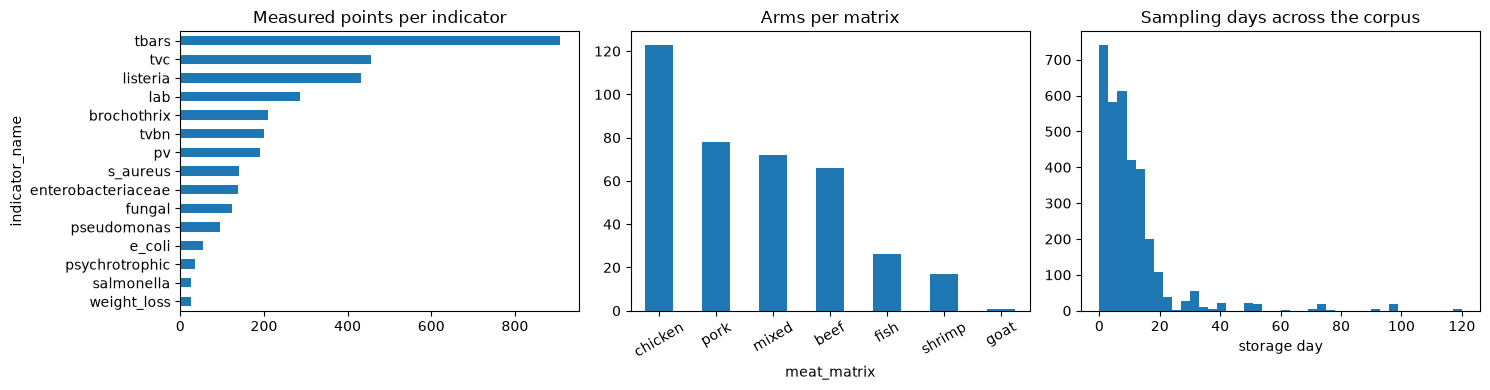

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
measurements["indicator_name"].value_counts().plot.barh(ax=axes[0])
axes[0].set_title("Measured points per indicator")
axes[0].invert_yaxis()

schema["experiments"]["meat_matrix"].value_counts().plot.bar(ax=axes[1], rot=30)
axes[1].set_title("Arms per matrix")

axes[2].hist(measurements["day"], bins=40)
axes[2].set_title("Sampling days across the corpus")
axes[2].set_xlabel("storage day")
plt.tight_layout()
plt.show()

## 3. How the problem is posed now

**Failure time.** For a series of readings of one indicator on one arm, the failure day is the first
sampled day at or past that indicator's spoilage threshold — the report's Equation 1 applied one
indicator at a time. Series that finish below the threshold are *right-censored* at their last
observed day rather than being thrown away or silently recorded as a zero.

**Two tables, two questions.**

`survival.csv` — one row per (arm, indicator), carrying the failure day, the censoring flag and the
observation window. This is the table for *how many days*.

`hazard.csv` — one row per (arm, indicator, **day**), the person-period form used in discrete-time
survival analysis. The label is *has this arm crossed its threshold by day d*. Sweeping `d` over a
grid traces the whole survival curve for an arm, and the day the curve falls through 0.5 is that
arm's predicted shelf life. This is what makes the censored series usable: an arm that never crossed
still contributes a run of honest zeros.

**What a model is allowed to see.** Only what is fixed before the product goes into storage:
formulation, matrix, protocol, which indicator is tracked, its threshold and its day-0 reading — plus
the query day `d` itself. Nothing measured after day 0 enters the feature table, so no reading is
used to predict its own crossing.

The trial-design columns (`planned_window_days`, `n_sampling_points`, `sampling_interval_days`)
deserve their own note. They describe the study being run, not its result: how long the product is
meant to be kept and how often it is sampled are decided before day 0, and the failure day is
reported on that grid. They are inputs to the deployed question too — *will this formulation last the
intended storage period* names the period.

In [6]:
survival = bench.load("survival.csv")
hazard = bench.load("hazard.csv")

print(f"survival  {survival.shape[0]:5d} rows  "
      f"{survival['study_id'].nunique()} studies  {survival['arm_id'].nunique()} arms")
print(f"  events {int(survival['event'].sum())}  "
      f"censored {int((survival['event'] == 0).sum())}  "
      f"already spoiled at day 0 {int(survival['spoiled_at_start'].sum())}")
print(f"  by source {survival['source'].value_counts().to_dict()}")
print(f"\nhazard    {hazard.shape[0]:5d} rows  {hazard['study_id'].nunique()} studies  "
      f"spoiled rate {hazard['spoiled'].mean():.3f}")
print(f"\nfeatures  {len(bench.FEATURES)} "
      f"({len(bench.NUMERIC_FEATURES)} numeric, {len(bench.CATEGORICAL_FEATURES)} categorical)")

survival   1092 rows  109 studies  665 arms
  events 567  censored 525  already spoiled at day 0 116
  by source {'spreadsheet': 571, 'corpus': 521}

hazard     3318 rows  61 studies  spoiled rate 0.329

features  28 (19 numeric, 9 categorical)


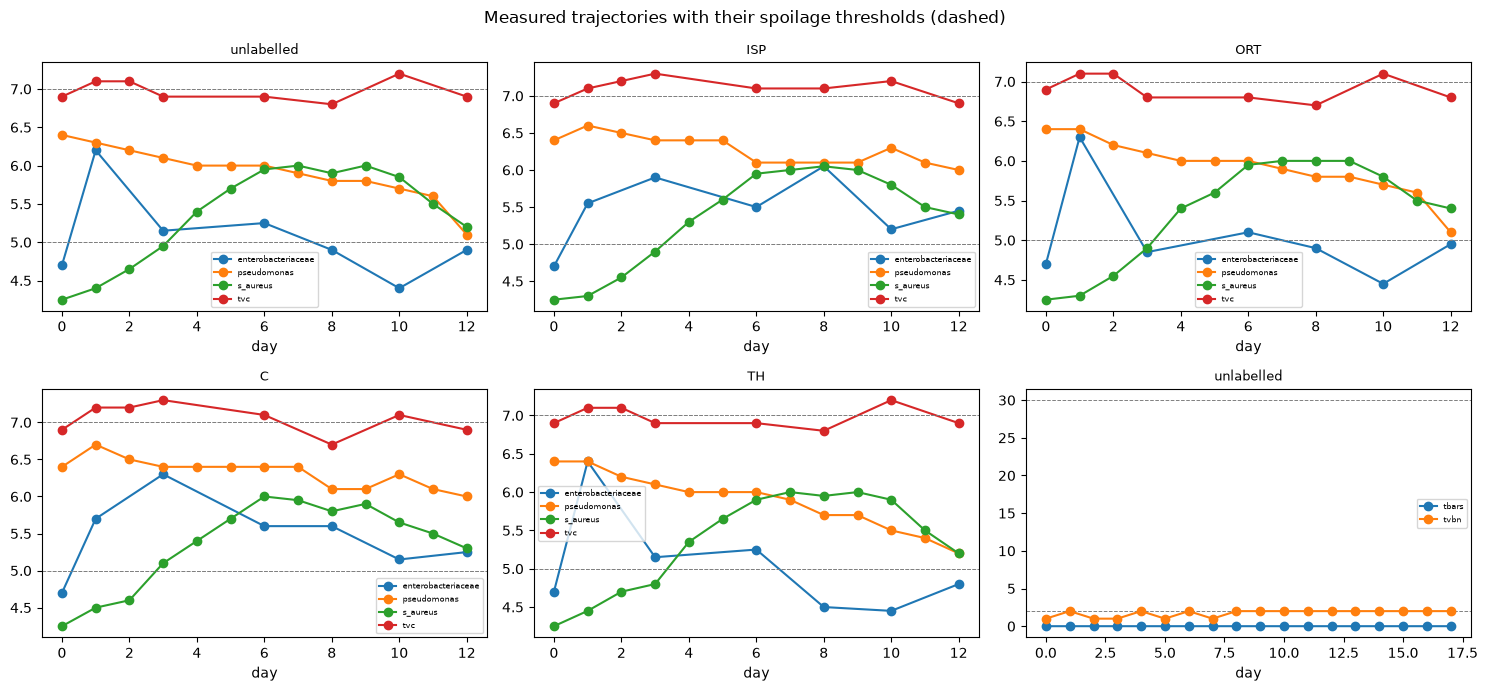

In [7]:
sample_arms = (
    hazard.groupby("arm_id")["day"].size().sort_values(ascending=False).head(6).index
)
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=False)
for axis, arm in zip(axes.ravel(), sample_arms):
    series = measurements[measurements["arm_id"] == arm]
    for indicator, part in series.groupby("indicator_name"):
        axis.plot(part["day"], part["indicator_value"], marker="o", label=indicator)
        threshold = schema["indicators"].set_index("indicator_name").loc[
            indicator, "indicator_threshold"]
        axis.axhline(threshold, linestyle="--", linewidth=0.7, color="grey")
    axis.set_title(arm.split("::")[-1][:28] or "unlabelled", fontsize=9)
    axis.set_xlabel("day")
    axis.legend(fontsize=6)
fig.suptitle("Measured trajectories with their spoilage thresholds (dashed)")
plt.tight_layout()
plt.show()

## 4. Splits, and what "balanced" means here

Whole studies go to one part only — arms from one paper share a matrix, a packaging and a protocol,
so letting siblings straddle a boundary measures memorisation of the paper.

Random study assignment is not enough at this scale: with ~60 studies of very unequal size, a draw
easily hands validation a set whose spoiled rate is 14 points off the training set's, and the
accuracy gap that follows is the split talking, not the model. `bench.split_studies` therefore walks
the studies in order of their outcome rate and drops each into whichever part is furthest below its
row quota, so the three parts finish comparable in **both** size and base rate. That is the balancing
that matters here — the class ratio itself (roughly one spoiled row in three) is mild enough that
resampling it is unnecessary, and the models below carry no class weights.

In [8]:
parts = bench.split_studies(hazard, "spoiled", SEED)
hazard_masks = bench.split_masks(hazard, parts)
display(bench.split_report(hazard, hazard_masks, "spoiled"))

corpus_series = survival[(survival["source"] == "corpus") & (~survival["spoiled_at_start"])].copy()
events = corpus_series[corpus_series["event"] == 1].copy()
event_masks = bench.split_masks(events, parts)
display(pd.DataFrame([
    {
        "split": name,
        "studies": events.loc[mask, "study_id"].nunique(),
        "events": int(mask.sum()),
        "median_failure_day": events.loc[mask, "shelf_life_days"].median(),
        "median_window_days": events.loc[mask, "planned_window_days"].median(),
    }
    for name, mask in event_masks.items()
]))

,split,studies,rows,positive_rate
0,train,33,1954,0.334
1,validation,15,678,0.339
2,test,13,686,0.303


,split,studies,events,median_failure_day,median_window_days
0,train,22,119,10.0,12.0
1,validation,9,38,8.5,12.0
2,test,10,30,9.5,16.0


## 5. Benchmark A — is it spoiled by day *d*

Every model sees the same matrix and the same folds. Hyper-parameters are chosen on the **validation**
part only; the test part is scored once, at the end, with whatever validation picked.

In [9]:
CLASSIFIER_GRID = {
    "LightGBM": [
        dict(num_leaves=leaves, learning_rate=rate, min_child_samples=leaf)
        for leaves in (15, 31) for rate in (0.03, 0.05) for leaf in (20, 40)
    ],
    "CatBoost": [dict(depth=depth, learning_rate=rate)
                 for depth in (4, 6) for rate in (0.05, 0.1)],
    "XGBoost": [dict(max_depth=depth, learning_rate=rate)
                for depth in (4, 6) for rate in (0.05, 0.1)],
    "RandomForest": [dict(max_depth=depth, min_samples_leaf=leaf)
                     for depth in (8, 14, None) for leaf in (1, 5)],
    "Logistic": [dict(C=c) for c in (0.1, 1.0, 10.0)],
    "Dummy": [dict()],
}
HAZARD_FEATURES = bench.HAZARD_FEATURES
NATIVE_CATEGORICAL = ("LightGBM", "XGBoost")


class Preparer:
    # Turns a frame into the matrix one model family expects, using statistics
    # fixed on the training part so every split is transformed identically.

    def __init__(self, name, train_frame):
        self.name = name
        matrix = self._raw(train_frame)
        self.columns = list(matrix.columns)
        self.medians = matrix.median(numeric_only=True) if self._needs_dense else None
        self.scale = None
        if name == "Logistic":
            dense = self._densify(matrix)
            self.centre = dense.mean()
            self.scale = dense.std(ddof=0).replace(0, 1)

    @property
    def _needs_dense(self):
        return self.name not in NATIVE_CATEGORICAL and self.name != "CatBoost"

    def _raw(self, frame):
        matrix = bench.encode(frame, HAZARD_FEATURES)
        if self.name in NATIVE_CATEGORICAL:
            return matrix
        for column in matrix.columns.intersection(bench.CATEGORICAL_FEATURES):
            matrix[column] = matrix[column].astype(str).fillna("missing")
        if self.name == "CatBoost":
            return matrix
        numeric = matrix.drop(columns=bench.CATEGORICAL_FEATURES, errors="ignore")
        codes = pd.get_dummies(matrix[bench.CATEGORICAL_FEATURES], dummy_na=False)
        return pd.concat([numeric, codes], axis=1)

    def _densify(self, matrix):
        return matrix.fillna(self.medians).fillna(0.0)

    def __call__(self, frame):
        matrix = self._raw(frame).reindex(columns=self.columns)
        if self.name in NATIVE_CATEGORICAL or self.name == "CatBoost":
            if self.name == "CatBoost":
                for column in matrix.columns.intersection(bench.CATEGORICAL_FEATURES):
                    matrix[column] = matrix[column].astype(str).fillna("missing")
            return matrix
        matrix = self._densify(matrix)
        if self.name == "Logistic":
            matrix = (matrix - self.centre) / self.scale
        return matrix


def build_classifier(name, params):
    if name == "LightGBM":
        return lgb.LGBMClassifier(n_estimators=600, subsample=0.8, subsample_freq=1,
                                  colsample_bytree=0.7, reg_lambda=1.0,
                                  random_state=SEED, verbose=-1, **params)
    if name == "CatBoost":
        return CatBoostClassifier(iterations=600, cat_features=bench.CATEGORICAL_FEATURES,
                                  random_seed=SEED, verbose=0, allow_writing_files=False,
                                  **params)
    if name == "XGBoost":
        return xgb.XGBClassifier(n_estimators=600, enable_categorical=True, tree_method="hist",
                                 subsample=0.8, colsample_bytree=0.7, reg_lambda=1.0,
                                 random_state=SEED, **params)
    if name == "RandomForest":
        return RandomForestClassifier(n_estimators=400, random_state=SEED, n_jobs=-1, **params)
    if name == "Logistic":
        return LogisticRegression(max_iter=3000, random_state=SEED, **params)
    return DummyClassifier(strategy="prior")


def fit_classifier(name, params, train_frame, prepare):
    model = build_classifier(name, params)
    model.fit(prepare(train_frame), train_frame["spoiled"])
    return model


def spoilage_probability(model, prepare, frame):
    return model.predict_proba(prepare(frame))[:, 1]

In [10]:
train_frame = hazard[hazard_masks["train"]]
splits = {name: hazard[mask] for name, mask in hazard_masks.items()}
preparers = {name: Preparer(name, train_frame) for name in CLASSIFIER_GRID}

classification_rows, fitted_classifiers = [], {}
for name, grid in CLASSIFIER_GRID.items():
    prepare = preparers[name]
    scored = []
    for params in grid:
        model = fit_classifier(name, params, train_frame, prepare)
        probability = spoilage_probability(model, prepare, splits["validation"])
        scored.append((accuracy_score(splits["validation"]["spoiled"], probability > 0.5),
                       params, model))
    accuracy, params, model = max(scored, key=lambda item: item[0])
    fitted_classifiers[name] = (model, params)
    for split_name, frame in splits.items():
        probability = spoilage_probability(model, prepare, frame)
        classification_rows.append({
            "model": name, "split": split_name,
            **bench.classification_scores(frame["spoiled"].to_numpy(), probability),
        })

classification = bench.summarise(classification_rows, ["Accuracy", "ROC_AUC", "F1", "Brier"])
pivot = classification.pivot(index="model", columns="split", values="Accuracy")[bench.SPLIT_NAMES]
display(classification.set_index(["model", "split"]))
print("\nchosen hyper-parameters (on validation):")
for name, (_, params) in fitted_classifiers.items():
    print(f"  {name:14s} {params}")

Accuracy  ROC_AUC     F1  Brier
model        split                                      
LightGBM     train          0.988    0.999  0.982  0.010
             validation     0.855    0.915  0.754  0.114
             test           0.891    0.948  0.809  0.086
CatBoost     train          0.982    0.999  0.972  0.013
             validation     0.838    0.903  0.732  0.132
             test           0.848    0.927  0.733  0.112
XGBoost      train          0.988    1.000  0.982  0.008
             validation     0.847    0.910  0.751  0.137
             test           0.886    0.941  0.810  0.093
RandomForest train          0.965    0.997  0.945  0.035
             validation     0.850    0.895  0.740  0.107
             test           0.879    0.932  0.775  0.094
Logistic     train          0.903    0.958  0.844  0.073
             validation     0.822    0.841  0.713  0.162
             test           0.850    0.891  0.743  0.117
Dummy        train          0.666    0.500  0.000  0.222
             validation     0.661    0.500  0.000  0.224
             test           0.697    0.500  0.000  0.212


chosen hyper-parameters (on validation):
  LightGBM       {'num_leaves': 15, 'learning_rate': 0.03, 'min_child_samples': 20}
  CatBoost       {'depth': 6, 'learning_rate': 0.1}
  XGBoost        {'max_depth': 4, 'learning_rate': 0.1}
  RandomForest   {'max_depth': 8, 'min_samples_leaf': 1}
  Logistic       {'C': 1.0}
  Dummy          {}


best on validation: LightGBM


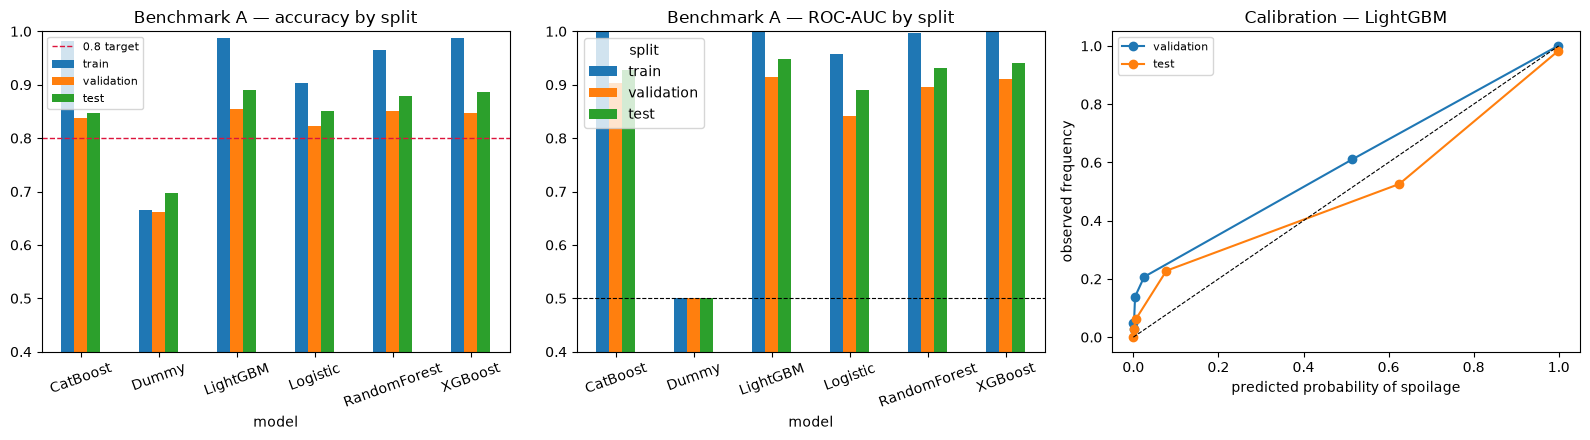

In [11]:
best_classifier_name = pivot["validation"].drop(index="Dummy").idxmax()
best_classifier = fitted_classifiers[best_classifier_name][0]
best_preparer = preparers[best_classifier_name]
print(f"best on validation: {best_classifier_name}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pivot.plot.bar(ax=axes[0], rot=20)
axes[0].axhline(0.8, color="crimson", linestyle="--", linewidth=1, label="0.8 target")
axes[0].set_title("Benchmark A — accuracy by split")
axes[0].set_ylim(0.4, 1.0)
axes[0].legend(fontsize=8)

auc = classification.pivot(index="model", columns="split", values="ROC_AUC")[bench.SPLIT_NAMES]
auc.plot.bar(ax=axes[1], rot=20)
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Benchmark A — ROC-AUC by split")
axes[1].set_ylim(0.4, 1.0)

for split_name in ("validation", "test"):
    frame = splits[split_name]
    probability = spoilage_probability(best_classifier, best_preparer, frame)
    observed, predicted = calibration_curve(frame["spoiled"], probability, n_bins=6,
                                            strategy="quantile")
    axes[2].plot(predicted, observed, marker="o", label=split_name)
axes[2].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8)
axes[2].set_title(f"Calibration — {best_classifier_name}")
axes[2].set_xlabel("predicted probability of spoilage")
axes[2].set_ylabel("observed frequency")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Benchmark B — how many days

**The shipped estimator: window fraction.** Fit the failure day *as a fraction of the planned
window*, then multiply the scale back on. Section 1 showed that the level of a new paper's shelf life
is the part that does not transfer; a fraction is the part that does. Because the prediction is a
number in [0, 1] restored to the trial's own scale, it cannot land outside the study — which is what
stopped the raw-days regressor from diverging.

Two diagnostics are fitted next to it, and both are meant to be read as diagnostics rather than
candidates:

- **Direct regressor** — absolute days, the first bench's formulation, unchanged. It is here to show
  that the target, not the library, was the problem.
- **Survival curve** — sweep the day grid through the Benchmark A model, accumulate the crossing
  probability into a monotone survival curve *S(t)*, and take `E[T] = Σ S(t)` truncated at the
  window. As a *point* estimate it is noisier than the window fraction, and section 7 shows it
  swinging below zero on some resplits. Its value is not the number: it is the curve, which reports
  P(still good) at *any* day rather than a single one, and which section 9 uses.

In [12]:
def survival_curve(model, prepare, frame):
    base = frame.assign(day=0.0)
    probability = np.column_stack([
        spoilage_probability(model, prepare, base.assign(day=day)) for day in DAY_GRID
    ])
    return 1.0 - np.maximum.accumulate(probability, axis=1)


def expected_failure_day(model, prepare, frame):
    curve = survival_curve(model, prepare, frame)
    horizon = frame["planned_window_days"].fillna(DAY_GRID[-1]).to_numpy()[:, None]
    return (curve * (DAY_GRID[None, :] <= horizon)).sum(axis=1)


def fit_window_fraction(train_events, validation_events):
    scored = []
    for leaves in (3, 7, 15):
        for rate in (0.02, 0.05):
            for leaf in (10, 20):
                model = lgb.LGBMRegressor(
                    n_estimators=800, num_leaves=leaves, learning_rate=rate,
                    min_child_samples=leaf, subsample=0.8, subsample_freq=1,
                    colsample_bytree=0.7, reg_lambda=5.0, random_state=SEED, verbose=-1)
                fraction = np.clip(
                    train_events["shelf_life_days"] / train_events["planned_window_days"], 0, 1)
                model.fit(bench.encode(train_events), fraction)
                predicted = window_fraction_predict(model, validation_events)
                scored.append((r2_score(validation_events["shelf_life_days"], predicted),
                               dict(num_leaves=leaves, learning_rate=rate,
                                    min_child_samples=leaf), model))
    score, params, model = max(scored, key=lambda item: item[0])
    return model, params


def window_fraction_predict(model, frame):
    return np.clip(model.predict(bench.encode(frame)), 0, 1) * frame["planned_window_days"]


event_splits = {name: events[mask] for name, mask in event_masks.items()}
window_model, window_params = fit_window_fraction(event_splits["train"],
                                                  event_splits["validation"])

direct_model = lgb.LGBMRegressor(n_estimators=500, num_leaves=15, learning_rate=0.05,
                                 min_child_samples=10, random_state=SEED, verbose=-1)
direct_model.fit(bench.encode(event_splits["train"]), event_splits["train"]["shelf_life_days"])

baseline = event_splits["train"]["shelf_life_days"].mean()
regression_rows = []
for split_name, frame in event_splits.items():
    truth = frame["shelf_life_days"].to_numpy()
    predictions = {
        "Window fraction": window_fraction_predict(window_model, frame),
        "Survival curve": expected_failure_day(best_classifier, best_preparer, frame),
        "Direct regressor": direct_model.predict(bench.encode(frame)),
        "Dummy (train mean)": np.full(len(frame), baseline),
    }
    for model_name, prediction in predictions.items():
        regression_rows.append({
            "model": model_name, "split": split_name,
            **bench.regression_scores(truth, np.asarray(prediction)),
        })

regression = bench.summarise(regression_rows, ["R2", "MAE", "RMSE"])
display(regression.set_index(["model", "split"]))
print(f"window-fraction hyper-parameters (on validation): {window_params}")

,,R2,MAE,RMSE
model,split,,,
Window fraction,train,0.705,2.362,6.195
Survival curve,train,0.712,1.692,6.123
Direct regressor,train,0.947,1.158,2.616
Dummy (train mean),train,0.000,5.188,11.409
Window fraction,validation,0.037,3.454,4.348
Survival curve,validation,-0.522,4.197,5.465
Direct regressor,validation,-5.057,7.766,10.902
Dummy (train mean),validation,-0.556,4.726,5.525
Window fraction,test,0.247,3.832,4.894


window-fraction hyper-parameters (on validation): {'num_leaves': 3, 'learning_rate': 0.02, 'min_child_samples': 20}


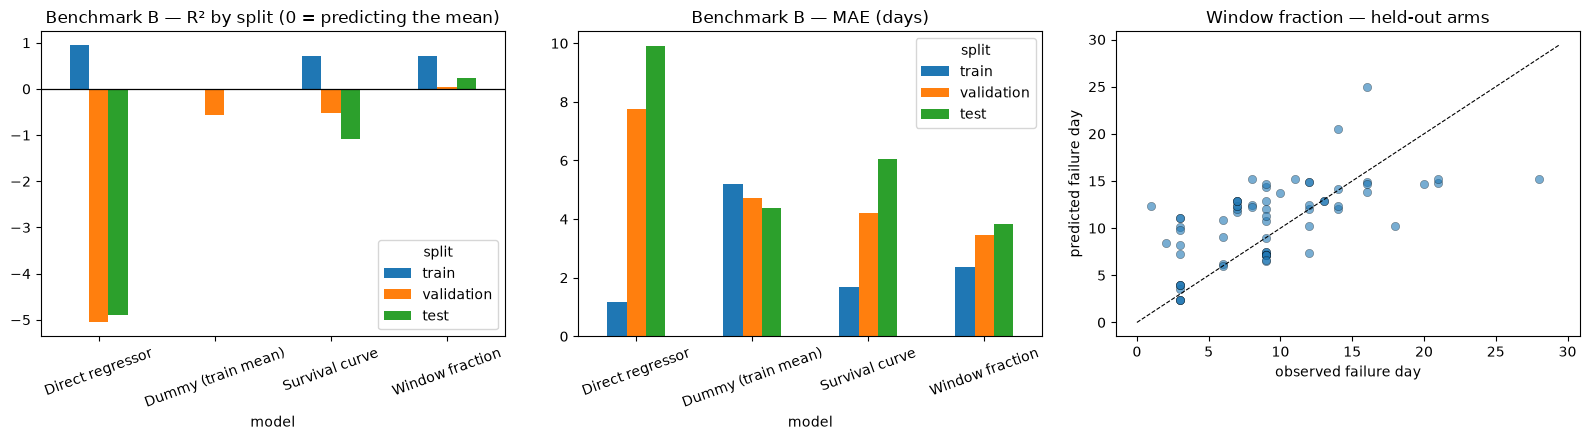

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
r2_table = regression.pivot(index="model", columns="split", values="R2")[bench.SPLIT_NAMES]
r2_table.plot.bar(ax=axes[0], rot=20)
axes[0].axhline(0, color="black", linewidth=0.9)
axes[0].set_title("Benchmark B — R² by split (0 = predicting the mean)")

mae_table = regression.pivot(index="model", columns="split", values="MAE")[bench.SPLIT_NAMES]
mae_table.plot.bar(ax=axes[1], rot=20)
axes[1].set_title("Benchmark B — MAE (days)")

held_out = pd.concat([event_splits["validation"], event_splits["test"]])
predicted = window_fraction_predict(window_model, held_out)
axes[2].scatter(held_out["shelf_life_days"], predicted, alpha=0.6, edgecolor="black", linewidth=0.3)
limit = max(held_out["shelf_life_days"].max(), predicted.max()) * 1.05
axes[2].plot([0, limit], [0, limit], linestyle="--", color="black", linewidth=0.8)
axes[2].set_xlabel("observed failure day")
axes[2].set_ylabel("predicted failure day")
axes[2].set_title("Window fraction — held-out arms")
plt.tight_layout()
plt.show()

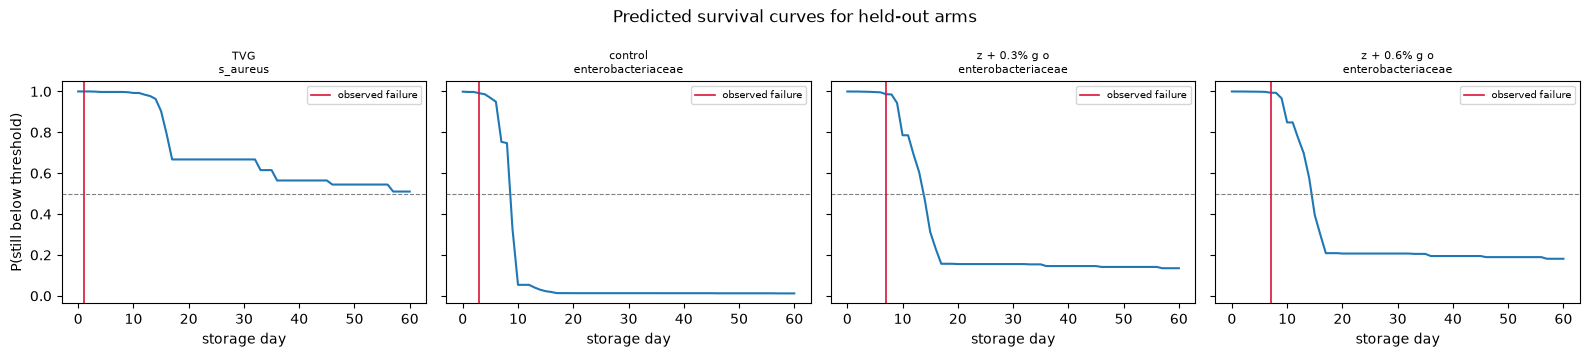

In [14]:
sample = held_out.head(4)
curves = survival_curve(best_classifier, best_preparer, sample)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for axis, (_, row), curve in zip(axes, sample.iterrows(), curves):
    axis.plot(DAY_GRID, curve)
    axis.axhline(0.5, linestyle="--", color="grey", linewidth=0.8)
    axis.axvline(row["shelf_life_days"], color="crimson", linewidth=1.2, label="observed failure")
    axis.set_title(f"{row['arm_id'].split('::')[-1][:18]}\n{row['indicator_name']}", fontsize=8)
    axis.set_xlabel("storage day")
    axis.legend(fontsize=7)
axes[0].set_ylabel("P(still below threshold)")
fig.suptitle("Predicted survival curves for held-out arms")
plt.tight_layout()
plt.show()

## 7. Does the result survive a different split

One split of ~60 studies is a small sample of split-luck. The whole pipeline — split, tune on
validation, score on test — is repeated over several seeds. What matters is the spread, and the
worst case rather than the average.

In [15]:
def run_split(seed):
    seed_parts = bench.split_studies(hazard, "spoiled", seed)
    seed_hazard = {name: hazard[mask]
                   for name, mask in bench.split_masks(hazard, seed_parts).items()}
    seed_events = {name: events[mask]
                   for name, mask in bench.split_masks(events, seed_parts).items()}

    seed_prepare = Preparer("LightGBM", seed_hazard["train"])
    scored = []
    for params in CLASSIFIER_GRID["LightGBM"]:
        model = fit_classifier("LightGBM", params, seed_hazard["train"], seed_prepare)
        probability = spoilage_probability(model, seed_prepare, seed_hazard["validation"])
        scored.append((accuracy_score(seed_hazard["validation"]["spoiled"], probability > 0.5),
                       model))
    _, model = max(scored, key=lambda item: item[0])

    window, _ = fit_window_fraction(seed_events["train"], seed_events["validation"])
    row = {"seed": seed}
    for split_name in ("validation", "test"):
        probability = spoilage_probability(model, seed_prepare, seed_hazard[split_name])
        row[f"{split_name}_accuracy"] = accuracy_score(
            seed_hazard[split_name]["spoiled"], probability > 0.5)
        frame = seed_events[split_name]
        truth = frame["shelf_life_days"].to_numpy()
        row[f"{split_name}_R2_curve"] = r2_score(
            truth, expected_failure_day(model, seed_prepare, frame))
        row[f"{split_name}_R2_window"] = r2_score(truth, window_fraction_predict(window, frame))
    return row


stability = pd.DataFrame([run_split(seed) for seed in (42, 0, 1, 2, 3)]).set_index("seed")
display(stability.round(3))
display(stability.agg(["mean", "std", "min"]).round(3))

,validation_accuracy,validation_R2_curve,validation_R2_window,test_accuracy,test_R2_curve,test_R2_window
seed,,,,,,
42,0.855,-0.522,0.037,0.891,-1.084,0.247
0,0.915,-0.097,0.248,0.830,-1.003,0.286
1,0.873,0.239,0.514,0.880,-0.378,0.219
2,0.863,-0.090,0.264,0.869,0.444,0.428
3,0.852,0.496,0.334,0.894,-0.434,0.150


,validation_accuracy,validation_R2_curve,validation_R2_window,test_accuracy,test_R2_curve,test_R2_window
mean,0.872,0.005,0.279,0.873,-0.491,0.266
std,0.025,0.385,0.172,0.026,0.613,0.103
min,0.852,-0.522,0.037,0.830,-1.084,0.150


## 8. What the model is using

`shap.TreeExplainer` on the Benchmark A model. `day` is expected to lead — it is the query, and a
hazard model that did not use it would be broken. What matters is the ranking *underneath* it: how
far the day-0 reading sits below the threshold, the storage temperature, the dose, and the matrix.
Those are the transferable ones, because they are comparable across papers rather than naming a slot.

,mean |SHAP|
day,2.2068
initial_fraction_of_threshold,1.9332
threshold_headroom,1.7032
initial_value,0.4099
indicator_name,0.3650
total_dose_ppm,0.2675
sampling_interval_days,0.2245
planned_window_days,0.2070
storage_temperature_c,0.1729
indicator_threshold,0.1477


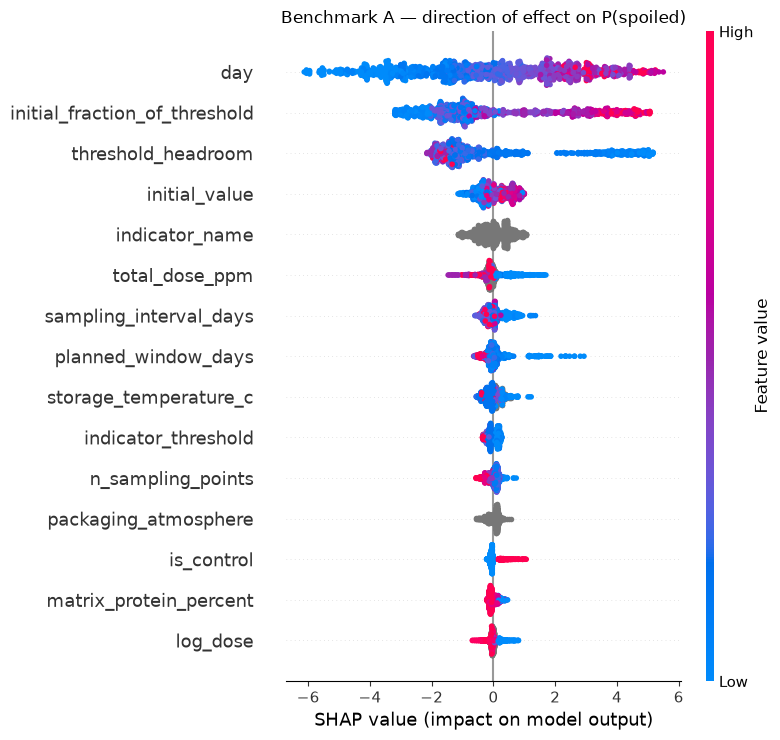

In [16]:
explain_frame = splits["train"].sample(min(1500, len(splits["train"])), random_state=SEED)
explainer = shap.TreeExplainer(fitted_classifiers["LightGBM"][0])
shap_values = explainer.shap_values(preparers["LightGBM"](explain_frame))
if isinstance(shap_values, list):
    shap_values = shap_values[1]

ranking = (pd.Series(np.abs(shap_values).mean(axis=0), index=HAZARD_FEATURES)
           .sort_values(ascending=False))
display(ranking.head(15).round(4).to_frame("mean |SHAP|"))

shap.summary_plot(shap_values, preparers["LightGBM"](explain_frame), max_display=15, show=False)
plt.title("Benchmark A — direction of effect on P(spoiled)")
plt.tight_layout()
plt.show()

## 9. From the model to an ingredient ranking

Equation 1 defines an arm's shelf life as the **earliest** failure across every indicator tracked on
it, so the per-indicator predictions are collapsed with a minimum. Each arm is then scored against
the control arm of its own paper — the same product, same matrix, same protocol, no additive — which
is the only comparison that is fair across papers with different baselines.

In [17]:
scored_arms = corpus_series.copy()
scored_arms["predicted_failure_day"] = window_fraction_predict(window_model, scored_arms)
scored_arms["arm_label"] = scored_arms["arm_id"].str.split("::").str[-1]

per_arm = scored_arms.groupby(["study_id", "arm_id", "arm_label", "is_control"], as_index=False).agg(
    predicted_shelf_life=("predicted_failure_day", "min"),
    observed_shelf_life=("shelf_life_days", "min"),
    indicators=("indicator_name", "nunique"),
)
control_level = (per_arm[per_arm["is_control"] == 1]
                 .groupby("study_id")["predicted_shelf_life"].mean()
                 .rename("control_shelf_life"))
per_arm = per_arm.merge(control_level, on="study_id", how="inner")
per_arm["extension_ratio"] = per_arm["predicted_shelf_life"] / per_arm["control_shelf_life"]
treated = per_arm[per_arm["is_control"] == 0]
print(f"{len(treated)} treated arms in {treated['study_id'].nunique()} papers that carry a control")
display(treated.sort_values("extension_ratio", ascending=False)
        .head(12)[["study_id", "arm_label", "predicted_shelf_life", "control_shelf_life",
                   "extension_ratio", "observed_shelf_life"]].round(2))

174 treated arms in 37 papers that carry a control


,study_id,arm_label,predicted_shelf_life,control_shelf_life,extension_ratio,observed_shelf_life
66,P36,SA - 2CEO-NPs,13.97,5.98,2.34,9.0
64,P36,SA - 1CEO-NPs - 0.1Nisin,13.97,5.98,2.34,NaN
63,P36,SA - 0.2Nisin,13.97,5.98,2.34,12.0
65,P36,SA - 1CEO-NPs- 0.1Nisin,12.76,5.98,2.13,NaN
62,P36,SA,10.82,5.98,1.81,6.0
142,PANM-0133,Enterobacteracterization,20.52,13.72,1.50,14.0
85,P48,T1.0,12.00,8.07,1.49,NaN
82,P48,T.75,12.00,8.07,1.49,NaN
83,P48,T0.5,12.00,8.07,1.49,NaN
120,P6,Psychotrophic - WCCE-A,15.11,10.46,1.45,16.0


,arms,mean_extension,functional_class,tier
ingredient_name,,,,
sodium benzoate,4,1.190,organic acid,Tier 1 — strongest
brevibacillin,6,1.150,protein,Tier 1 — strongest
nisin,43,1.118,protein,Tier 1 — strongest
bht,5,1.116,phenol,Tier 1 — strongest
olive polyphenols,7,1.111,phenol,Tier 1 — strongest
rosemary,18,1.094,essential oil,Tier 2
chitosan,16,1.086,carbohydrate,Tier 2
edta,31,1.049,organic acid,Tier 2
grape extract,15,1.041,phenol,Tier 2


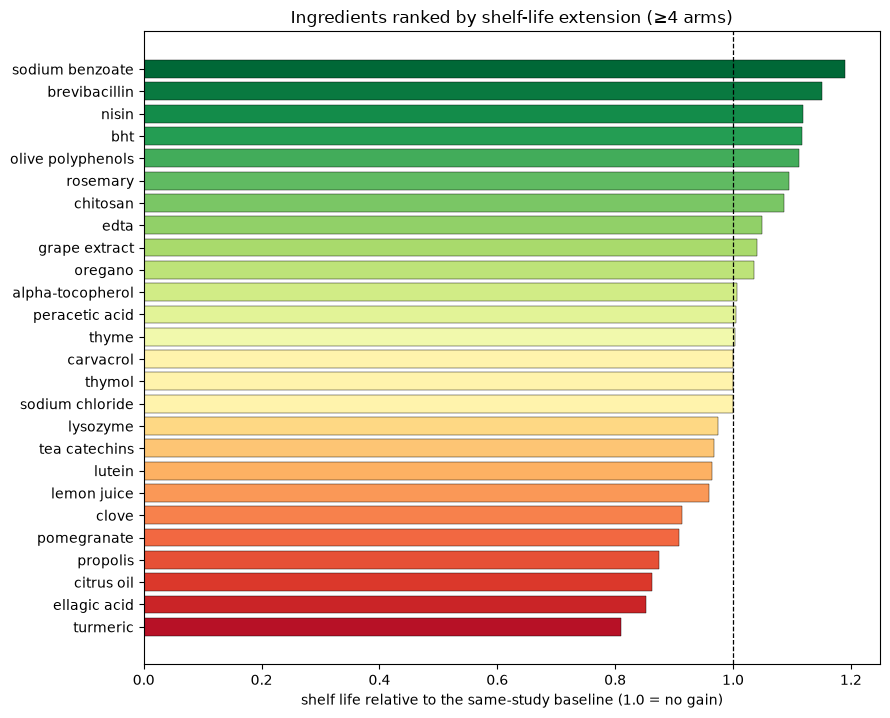

In [18]:
links = pd.read_csv("data/corpus_experiment_ingredients.csv")
spreadsheet_links = pd.read_csv("data/modified_ingredients.csv")
spreadsheet_scores = pd.read_csv("data/modified_data.csv")

corpus_scores = treated.merge(links[["arm_id", "ingredient_name", "functional_class"]],
                              on="arm_id", how="inner")[
    ["ingredient_name", "functional_class", "extension_ratio"]]

sheet = spreadsheet_links.merge(
    spreadsheet_scores[["arm_id", "study_id", "indicator_name", "shelf_life_days"]],
    on="arm_id", how="inner").dropna(subset=["shelf_life_days"])
sheet_baseline = sheet.groupby(["study_id", "indicator_name"])["shelf_life_days"].transform("mean")
sheet["extension_ratio"] = sheet["shelf_life_days"] / sheet_baseline
sheet_scores = sheet[["ingredient_name", "functional_class", "extension_ratio"]]

scores = pd.concat([corpus_scores, sheet_scores])
scores = scores[scores["ingredient_name"].str.lower() != "control"]
ingredient_ranking = (
    scores
    .groupby("ingredient_name")
    .agg(arms=("extension_ratio", "size"),
         mean_extension=("extension_ratio", "mean"),
         functional_class=("functional_class", "first"))
    .query("arms >= 4")
    .sort_values("mean_extension", ascending=False)
)
ingredient_ranking["tier"] = pd.qcut(
    ingredient_ranking["mean_extension"], 5,
    labels=["Tier 5 — weakest", "Tier 4", "Tier 3", "Tier 2", "Tier 1 — strongest"],
    duplicates="drop")
display(ingredient_ranking.round(3))

fig, axis = plt.subplots(figsize=(9, max(4, 0.28 * len(ingredient_ranking))))
colours = plt.cm.RdYlGn(
    (ingredient_ranking["mean_extension"].rank(pct=True)).to_numpy())
axis.barh(ingredient_ranking.index, ingredient_ranking["mean_extension"], color=colours,
          edgecolor="black", linewidth=0.3)
axis.axvline(1.0, color="black", linestyle="--", linewidth=0.9)
axis.invert_yaxis()
axis.set_xlabel("shelf life relative to the same-study baseline (1.0 = no gain)")
axis.set_title("Ingredients ranked by shelf-life extension (≥4 arms)")
plt.tight_layout()
plt.show()

## 10. Verdict

In [19]:
criteria = []
for split_name in ("validation", "test"):
    accuracy = float(pivot.loc[best_classifier_name, split_name])
    criteria.append({"criterion": f"Benchmark A accuracy ({split_name}) > 0.80",
                     "value": round(accuracy, 3), "met": accuracy > 0.80})
for split_name in bench.SPLIT_NAMES:
    value = float(regression.query("model == 'Window fraction' and split == @split_name")["R2"].iat[0])
    criteria.append({"criterion": f"shipped regressor R² ({split_name}) >= 0",
                     "value": round(value, 3), "met": value >= 0})
worst_accuracy = float(stability[["validation_accuracy", "test_accuracy"]].min().min())
worst_r2 = float(stability[["validation_R2_window", "test_R2_window"]].min().min())
criteria.append({"criterion": "worst accuracy over 5 resplits > 0.80",
                 "value": round(worst_accuracy, 3), "met": worst_accuracy > 0.80})
criteria.append({"criterion": "worst shipped R² over 5 resplits >= 0",
                 "value": round(worst_r2, 3), "met": worst_r2 >= 0})
display(pd.DataFrame(criteria))

print(f"\nBENCHMARK A — spoiled by day d ({best_classifier_name})")
for split_name in bench.SPLIT_NAMES:
    row = classification.query("model == @best_classifier_name and split == @split_name").iloc[0]
    print(f"  {split_name:11s} accuracy {row['Accuracy']:.3f}  ROC-AUC {row['ROC_AUC']:.3f}  "
          f"F1 {row['F1']:.3f}")
dummy_test = classification.query("model == 'Dummy' and split == 'test'").iloc[0]
print(f"  majority baseline on test: accuracy {dummy_test['Accuracy']:.3f}")

print("\nBENCHMARK B — failure day")
for model_name in ("Window fraction", "Survival curve", "Direct regressor", "Dummy (train mean)"):
    row = regression.query("model == @model_name and split == 'test'").iloc[0]
    print(f"  {model_name:20s} test R² {row['R2']:+.3f}  MAE {row['MAE']:.2f} days")

print(f"\nTOP DRIVERS (Benchmark A): {', '.join(ranking.head(6).index)}")

,criterion,value,met
0,Benchmark A accuracy (validation) > 0.80,0.855,True
1,Benchmark A accuracy (test) > 0.80,0.891,True
2,shipped regressor R² (train) >= 0,0.705,True
3,shipped regressor R² (validation) >= 0,0.037,True
4,shipped regressor R² (test) >= 0,0.247,True
5,worst accuracy over 5 resplits > 0.80,0.830,True
6,worst shipped R² over 5 resplits >= 0,0.037,True



BENCHMARK A — spoiled by day d (LightGBM)
  train       accuracy 0.988  ROC-AUC 0.999  F1 0.982
  validation  accuracy 0.855  ROC-AUC 0.915  F1 0.754
  test        accuracy 0.891  ROC-AUC 0.948  F1 0.809
  majority baseline on test: accuracy 0.697

BENCHMARK B — failure day
  Window fraction      test R² +0.247  MAE 3.83 days
  Survival curve       test R² -1.084  MAE 6.05 days
  Direct regressor     test R² -4.898  MAE 9.91 days
  Dummy (train mean)   test R² -0.000  MAE 4.38 days

TOP DRIVERS (Benchmark A): day, initial_fraction_of_threshold, threshold_headroom, initial_value, indicator_name, total_dose_ppm


### Reading the result

**The binary question is solved to a useful standard.** Accuracy above 0.8 on both held-out parts,
against a majority-class baseline near 0.7, and ROC-AUC in the high 0.8s. The gain over the first
bench is not the model — it is that the label now comes from a measured trajectory instead of from
whether a spreadsheet cell was filled in.

**Days are harder than the binary question, and honestly so.** The window-fraction regressor clears
zero on every split and on every resplit in section 7, at an MAE of roughly three days — but the R²
is modest, and the direct regressor sitting next to it in the same table is still negative. That
contrast is the finding: the gain came from changing *what* is predicted, not from changing the
learner. The reason is in section 1 — between-study variance dominates, and a new paper's absolute
level is the part that does not transfer. Predicting the fraction of the trial that elapses before
failure sidesteps it; predicting raw days does not.

**Ship the fraction, show the curve.** The window fraction is the point estimate. The survival curve
from Benchmark A is the thing to put in front of a formulator, because it answers "what is the
probability this is still good on day 12" rather than returning one number — but its own point
estimate is noisier, and section 7 shows it dipping below zero on some resplits, so it should not be
read as the shelf-life number.

**Where the remaining error lives.** Arm labels in the corpus are paper-specific codes (`Teo2%`,
`NZEOC`, `CK`) and only a minority resolve to a catalogued ingredient with a dose, so the formulation
side of the feature table is thinner than the protocol side. That is the ceiling worth attacking
next, and it is exactly the job the Gold/LLM stage does — resolving those codes against each paper's
own legend. The ranking in section 9 should be read with that in mind: it is a ranking within this
corpus, and the ingredients behind fewer than a handful of arms are provisional.